# Tier 12: rotor speed physics, calibrated on the full-scale JVX proprotor

The external review's first point was that the rotor model couldn't see
rotor speed. The actuator disk used a constant hover figure of merit (0.67)
and a constant cruise coefficient (0.87). `MomentumProfileRotor` replaces it:

CP = CT lambda + kappa CT lambda_i + (sigma / 2) c_d I(lambda)

- lambda_i is the momentum inflow;
- I(lambda) is the profile power of sections at sqrt((Omega r)^2 + V^2);
- c_d is one drag polar in blade loading referred to the mean section
  dynamic pressure, plus an airplane-mode increment.

Power now depends on rotor speed, solidity and tip speed.

**Data:** C. W. Acree, NASA/TM-2016-219070 (2016), Appendix D, parsed into
`data/rotors/`:

- JVX hover: Tables D-1 and D-2;
- Phase II NFAC airplane mode: Tables D-7a and D-7c.

The JVX rotor is 25 ft in diameter with solidity 0.1138.

```powershell
uv run jupyter lab notebooks/tier12_rotor_physics
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from examples.halo_sizing import HaloAssumptions, solve_halo_sizing
from examples.jvx_rotor_calibration import calibration_report, jvx_rotor, load_airplane, load_hover, predict

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Calibration

The fits are linear least squares in the drag terms. kappa is fixed at 1.15,
because free fits put it below 1: the induced term (CT^1.5) and the loading
term (CT^2) are collinear over the test range. The Mtip 0.73 hover points
are held out of the fit as a check.

In [2]:
report = calibration_report()
print(f"hover polar (d0, d1, d2) = {tuple(round(float(c), 5) for c in report.polar)}")
print(f"airplane increment (a, b) = {tuple(round(float(c), 5) for c in report.increment)}")
print(f"hover FM RMS {report.hover_fm_rms:.4f}; Mtip 0.73 power error max {report.hover_d2_power_error_max:.4f}")
print(f"airplane efficiency RMS {report.airplane_eta_rms:.4f}, max {report.airplane_eta_max:.4f}")
check("hover figure-of-merit RMS error below 0.015", report.hover_fm_rms < 0.015)
check("held-out Mtip 0.73 hover power within 3 %", report.hover_d2_power_error_max < 0.03)
check("airplane-mode efficiency RMS below 0.015, max below 0.04",
      report.airplane_eta_rms < 0.015 and report.airplane_eta_max < 0.04)
bucket = -report.polar[1] / (2 * report.polar[2])
check("drag bucket at a physical blade loading (CT/sigma 0.05-0.15)", 0.05 < bucket < 0.15)

hover polar (d0, d1, d2) = (0.0185, -0.22164, 1.06625)
airplane increment (a, b) = (0.00169, 0.01876)
hover FM RMS 0.0123; Mtip 0.73 power error max 0.0216
airplane efficiency RMS 0.0128, max 0.0363
PASS  hover figure-of-merit RMS error below 0.015
PASS  held-out Mtip 0.73 hover power within 3 %
PASS  airplane-mode efficiency RMS below 0.015, max below 0.04
PASS  drag bucket at a physical blade loading (CT/sigma 0.05-0.15)


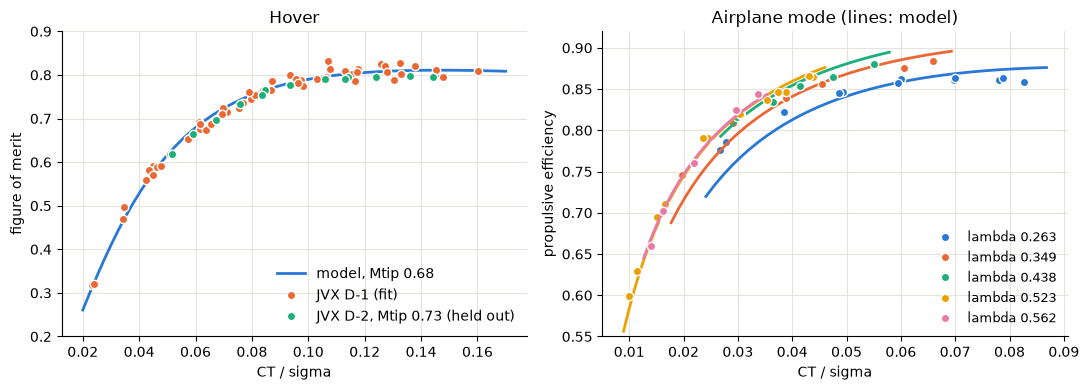

In [3]:
hover, airplane = load_hover(), load_airplane()
rotor = jvx_rotor(report.polar, report.increment)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
loads = np.linspace(0.02, 0.17, 60)
axes[0].plot(loads, [predict(rotor, x, 0.0, 0.68)[1] for x in loads], color=palette[0], lw=2, label="model, Mtip 0.68")
for table, color, label in (("D-1", palette[1], "JVX D-1 (fit)"), ("D-2", palette[2], "JVX D-2, Mtip 0.73 (held out)")):
    m = np.array([t == table for t in hover.table])
    axes[0].plot(hover.blade_loading[m], hover.figure_of_merit[m], "o", color=color, ms=6, mec="white", mew=1, label=label)
axes[0].set(xlabel="CT / sigma", ylabel="figure of merit", title="Hover", ylim=(0.2, 0.9))
axes[0].legend(frameon=False, loc="lower right")
for i, lam in enumerate((0.263, 0.349, 0.438, 0.523, 0.562)):
    m = np.abs(airplane.advance_ratio - lam) < 0.012
    xs = np.linspace(airplane.blade_loading[m].min() * 0.9, airplane.blade_loading[m].max() * 1.05, 40)
    axes[1].plot(xs, [predict(rotor, x, lam, 0.58)[1] for x in xs], color=palette[i], lw=2)
    axes[1].plot(airplane.blade_loading[m], airplane.efficiency[m], "o", color=palette[i], ms=6, mec="white", mew=1,
                 label=f"lambda {lam}")
axes[1].set(xlabel="CT / sigma", ylabel="propulsive efficiency", title="Airplane mode (lines: model)", ylim=(0.55, 0.92))
axes[1].legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 2. What rotor speed does now, and the limitation

At a fixed thrust, slowing the rotor cuts profile power, which scales as
Omega^3. In hover, blade loading pushes back: loading rises as 1/Omega^2, up
the drag polar. In airplane mode the loading reference (1 + 3 lambda^2) makes
the blades look lightly loaded, and the model has no blade-stall physics. So
cruise power keeps falling as the rotor slows, all the way out of the
calibrated range.

`advance_ratio_max` = 0.60 (the JVX data reach 0.56) is therefore a validity
bound. In sizing, that bound, not the physics, sets cruise rotor speed. BEM
with stall is the remedy, deferred to a later tier.

PASS  inside the validity bound, cruise power falls monotonically as the rotor slows


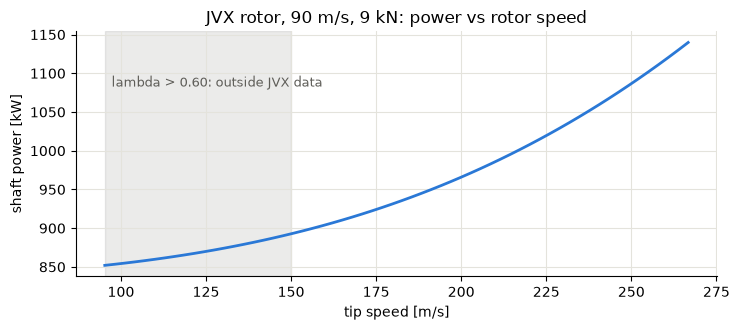

In [4]:
cruise = rotor.in_airplane_mode()
sea = asb.Atmosphere(altitude=0)
speeds = np.linspace(25, 70, 60)
radius = float(cruise.radius_m())
powers = np.array([float(cruise.evaluate(90.0, sea, thrust_N=9000.0, speed_rad_s=s).shaft_power_W) for s in speeds])
lam = 90.0 / (speeds * radius)
valid = lam <= cruise.advance_ratio_max
check("inside the validity bound, cruise power falls monotonically as the rotor slows",
      np.all(np.diff(powers[valid]) > 0))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(speeds * radius, powers / 1e3, color=palette[0], lw=2)
ax.axvspan(speeds[0] * radius, 90.0 / cruise.advance_ratio_max, color=ink_muted, alpha=0.12)
ax.text(speeds[0] * radius + 2, powers.max() / 1e3 * 0.95, "lambda > 0.60: outside JVX data", color=ink_muted, fontsize=9)
ax.set(xlabel="tip speed [m/s]", ylabel="shaft power [kW]", title="JVX rotor, 90 m/s, 9 kN: power vs rotor speed")
plt.tight_layout()
plt.show()

## 3. Halo-class aircraft with the new rotor

In [5]:
new = solve_halo_sizing()
old = solve_halo_sizing(assumptions=replace(HaloAssumptions(), rotor_speed_physics=False))
d = new.design
print(f"actuator disk (Tier 10c/11a): {old.mass_takeoff_kg / u.lbm:,.0f} lb; Tier 12 rotor: {new.mass_takeoff_kg / u.lbm:,.0f} lb")
print(f"solidity {d.solidity:.3f}, design tip speed {d.speed_tip_m_s:.0f} m/s, rotor diameter {2 * new.radius_rotor_m / u.foot:.1f} ft")
print(f"motors {new.power_rated_motor_W / 1e3:,.0f} kW (was {old.power_rated_motor_W / 1e3:,.0f}); battery "
      f"{d.power_max_discharge_battery_W / 1e3:,.0f} kW (was {old.design.power_max_discharge_battery_W / 1e3:,.0f})")
for s in new.segments:
    tip = s["speed_motor_rad_s"] / HaloAssumptions().reduction_ratio * new.radius_rotor_m
    print(f"  {s['label']:<15} tip speed {tip:6.1f} m/s ({tip / d.speed_tip_m_s:5.1%} of design)")
check("actuator-disk option still reproduces 18,506 lb", abs(old.mass_takeoff_kg / u.lbm - 18506) < 5)
check("JVX-calibrated rotor lowers take-off weight", new.mass_takeoff_kg < old.mass_takeoff_kg)
check("every constraint satisfied", new.min_margin > -1e-6)
cruise_seg = next(s for s in new.segments if s["label"] == "cruise")
lam_cruise = new.velocity_cruise_m_s / (cruise_seg["speed_motor_rad_s"] / HaloAssumptions().reduction_ratio * new.radius_rotor_m)
check("cruise sits on the lambda = 0.60 validity bound (documented limitation)", abs(lam_cruise - 0.60) < 1e-3)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


CasADi - 2026-10-03 09:42:39 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 136, col 0).") [.../casadi/core/oracle_function.cpp:408]


actuator disk (Tier 10c/11a): 18,506 lb; Tier 12 rotor: 17,227 lb
solidity 0.074, design tip speed 238 m/s, rotor diameter 30.5 ft
motors 957 kW (was 1,419); battery 750 kW (was 1,635)
  take-off hover  tip speed  219.8 m/s (92.3% of design)
  climb           tip speed  133.3 m/s (56.0% of design)
  cruise          tip speed  146.1 m/s (61.3% of design)
  reserve loiter  tip speed  112.2 m/s (47.1% of design)
  descent         tip speed  133.3 m/s (56.0% of design)
  landing hover   tip speed  203.0 m/s (85.2% of design)
PASS  actuator-disk option still reproduces 18,506 lb
PASS  JVX-calibrated rotor lowers take-off weight
PASS  every constraint satisfied
PASS  cruise sits on the lambda = 0.60 validity bound (documented limitation)


**Reading the result.**

- **Why it's lighter.** Most of the saving is hover power: a JVX-class rotor
  reaches a figure of merit of about 0.8, against the XV-15 metal blades'
  0.67. That shrinks the motors, gearboxes, and the battery's engine-out
  power.
- **What sets the rotor.** The optimizer chooses low solidity at the highest
  allowed hover tip speed, and the largest rotor that fits the span.
- **Cruise rotor speed.** Cruise runs at about 61 % of design tip speed, held
  there by the lambda bound. The real optimum for a stall-limited proprotor
  is nearer 80 %.

Treat this as an optimistic lower bound on cruise power until a BEM rotor
with stall replaces the bound.

## 4. Summary and unit test suite

In [6]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

9 / 9 notebook checks passed


In [7]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 261 tests in 26.372s

OK
